# LABORATORIO 4 - IA
* DULCE AMBROSIO - 231143
* DANIEL CHET - 231177
* GADIEL OCAÑA - 231270


# **--------- TASK 2.1 ---------**

In [1]:
#  GENERACION DE DATOS
import numpy as np
import matplotlib.pyplot as plt
import time

np.random.seed(42)

# Generamos 1000 puntos entre -3 y 3
x = np.linspace(-3, 3, 1000)

# Función 
y_true = 2*x**3 - 3*x**2 + 5*x + 3

In [2]:
# SE AGREGA RUIDO 
# Ya que los datos en la vida real no son perfectos
# entonces se agrega ruido para que todos los metodos no 
# convergan igual

noise = np.random.normal(0, 10, size=x.shape)
y = y_true + noise


In [3]:
# SE REALIZA LA NORMALIZACION
# Para que los valores de x^3 no se han demasiados grandes, al igual que el gradiente
# ya que el SGD pude volverse inestable

x_mean = np.mean(x)
x_std = np.std(x)

x_norm = (x - x_mean) / x_std


In [4]:
# SE GENERA LA MATRIZ DE LOS FEATURES

X = np.vstack([x_norm**3, x_norm**2, x_norm, np.ones(len(x_norm))]).T


In [5]:
# FUNCION DE COSTO

def compute_loss(X, y, w):
    n = len(y)
    y_pred = X @ w
    return (1/n) * np.sum((y_pred - y)**2)

---------------------------------------------------------------
RELACION CON DIAPOSITIVA: (Slide 26)

En la presentacion se define:
TrainLoss(w) = (1/|D_train|) ∑ Loss(x,y,w)

Aqui implementamos esa idea usando Mean Squared Error (MSE):

J(w) = (1/n) ||Xw - y||^2

Es la funcion que mide que tan bueno es nuestro predictor, 
equivalente a la funcion de perdida 

---------------------------------------------------------------

In [6]:
# BATCH GRADIENT DESCENT

def batch_gradient_descent(X, y, lr=0.01, epochs=100):
    n, d = X.shape
    w = np.random.randn(d)
    
    losses = []
    times = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        y_pred = X @ w
        
        gradient = (2/n) * X.T @ (y_pred - y)
        
        w = w - lr * gradient
        
        losses.append(compute_loss(X, y, w))
        times.append(time.time() - start_time)
    
    return w, losses, times


 ---------------------------------------------------------------
RELACION CON DIAPOSITIVA: "Gradiente Descendiente" (Slide 50)

En la presentacion se describe:
Calcular la gradiente → dar un pequeño paso en direccion -gradiente → repetir

Matematicamente:
    w = w - η ∇J(w)

En esta implementacion usamos el gradiente completo:
    ∇J(w) = (2/n) X^T (Xw - y)

Batch GD utiliza TODOS los datos para calcular el gradiente exacto,
lo que produce actualizaciones estables y deterministicas.

---------------------------------------------------------------

In [7]:
# STOCHASTIC GRADIENT DESCENT

def stochastic_gradient_descent(X, y, lr=0.01, epochs=100):
    n, d = X.shape
    w = np.random.randn(d)
    
    losses = []
    times = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        for i in range(n):
            idx = np.random.randint(0, n)
            xi = X[idx]
            yi = y[idx]
            
            y_pred = xi @ w
            
            gradient = 2 * xi * (y_pred - yi)
            
            w = w - lr * gradient
        
        losses.append(compute_loss(X, y, w))
        times.append(time.time() - start_time)
    
    return w, losses, times


---------------------------------------------------------------
RELACION CON DIAPOSITIVA: "Gradiente Descendiente Estocastico" (Slides 23-24)

En la presentacion dice que SGD:
"Itera sobre los ejemplos (x,y) y actualiza los pesos basado
en cada ejemplo individual".

Aqui implementamos:
    w = w - η * (2 * xi * (xi·w - yi))

Es decir, usamos una sola muestra para estimar el gradiente.
Esto introduce varianza en la actualizacion, generando
oscilaciones como se observa en la grafica.

---------------------------------------------------------------

In [8]:
# MINI BATCH GRADIENT DESCENT (N=32)

def mini_batch_gradient_descent(X, y, lr=0.01, epochs=100, batch_size=32):
    n, d = X.shape
    w = np.random.randn(d)
    
    losses = []
    times = []
    
    start_time = time.time()
    
    for epoch in range(epochs):
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]
        
        for i in range(0, n, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            m = len(y_batch)
            
            y_pred = X_batch @ w
            gradient = (2/m) * X_batch.T @ (y_pred - y_batch)
            
            w = w - lr * gradient
        
        losses.append(compute_loss(X, y, w))
        times.append(time.time() - start_time)
    
    return w, losses, times


---------------------------------------------------------------
RELACION CON DIAPOSITIVA: "Mini-batch SGD"

En la presentacion se menciona que Mini-batch:
 - Aleatoriza los ejemplos
 - Usa subconjuntos en cada actualizacion

Aqui implementamos esa idea:
 1) Aleatorizamos los datos con np.random.permutation
 2) Calculamos el gradiente sobre un subconjunto (batch_size=32)

Esto reduce la varianza del gradiente comparado con SGD,
pero mantiene menor costo computacional que Batch GD.

---------------------------------------------------------------

In [9]:
# ENTRENAMIENTO DE LOS 3 MODELOS CON LA MISMA CANTIDAD DE EPOCHS

epochs = 50
lr = 0.01

w_batch, loss_batch, time_batch = batch_gradient_descent(X, y, lr, epochs)
w_sgd, loss_sgd, time_sgd = stochastic_gradient_descent(X, y, lr, epochs)
w_mini, loss_mini, time_mini = mini_batch_gradient_descent(X, y, lr, epochs)


---------------------------------------------------------------
RELACION CON DIAPOSITIVA: "Tamaño del Paso" (Slide 25)

El parametro 'lr' corresponde al η (eta) mostrado en clase.
Este controla el tamaño del paso en cada actualizacion:

w = w - η ∇J(w)

Un η muy grande puede causar oscilaciones.
Un η muy pequeño puede hacer la convergencia muy lenta.

---------------------------------------------------------------

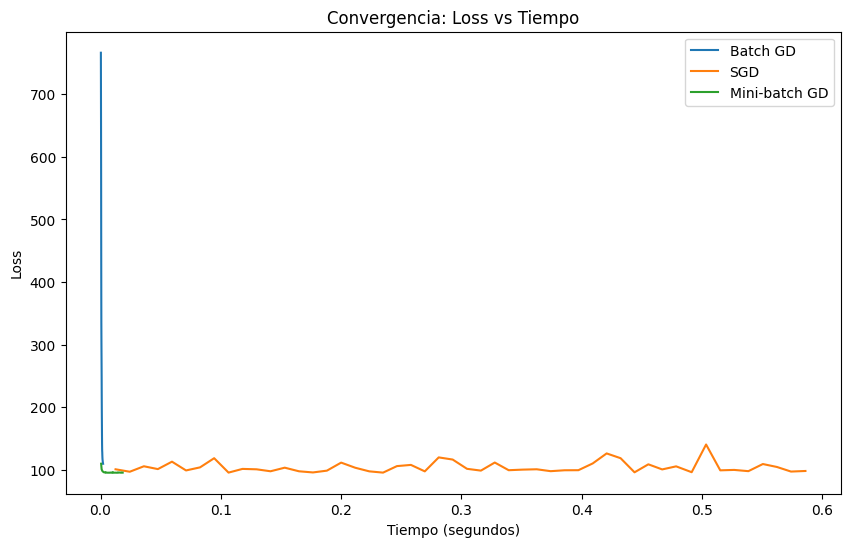

In [10]:
# GRAFICA DE CONVERGENCIA (LOSS VS TIEMPO)

plt.figure(figsize=(10,6))
plt.plot(time_batch, loss_batch, label="Batch GD")
plt.plot(time_sgd, loss_sgd, label="SGD")
plt.plot(time_mini, loss_mini, label="Mini-batch GD")
plt.xlabel("Tiempo (segundos)")
plt.ylabel("Loss")
plt.legend()
plt.title("Convergencia: Loss vs Tiempo")
plt.show()


# **--------- TASK 2.2 ---------**

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [12]:
# SE CARGA IRIS
iris = load_iris()
X = iris.data
y = iris.target

# SE SELECCIONA SOLO SETOS(0) Y VERSICOLOR (1)
mask = y < 2
X = X[mask]
y = y[mask]

# SE SELECCIONAN 2 FEATURES
# 0 = SEPAL LENGTH
# 1 = SEPAL WIDTH
X = X[:, :2]

# SE CONVIERTEN LAS ETIQUETAS
y = np.where(y == 0, -1, 1)

print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (100, 2)
Shape y: (100,)


In [13]:
class Perceptron:
    
    def __init__(self, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
    
    def activation(self, z):
        # FUNCION SIGNO
        return np.where(z >= 0, 1, -1)
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # INICIALIZACION DE PESO Y BIAS
        self.weights = np.random.randn(n_features)
        self.bias = np.random.randn()
        
        for epoch in range(self.epochs):
            for i in range(n_samples):
                linear_output = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear_output)
                
                error = y[i] - y_pred
                
                # REGLA DE ACTUALIZACION DE PERCEPTRON
                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation(linear_output)


---------------------------------------------------------------
RELACION CON DIAPOSITIVA: "Pesos y Capas" (Slides 42-44)

* El perceptron es la neurona fundamental
    Cada neurona realiza:

        z = w·x + b

    donde:
        w = pesos
        b = bias

* Luego aplica una funcion de activación (step o sign)
    Esta clase implementa exactamente esa estructura


* Los pesos son inicializados aleatoriamente antes del entrenamiento.

* Luego seran ajustados durante el proceso de aprendizaje
usando gradiente descendente (regla de actualizacion) (slide 48)

* La función de activación determina si la neurona produce clase +1 o -1.
Aquí usamos la función signo:
     y = sign(z)

Esto convierte la salida lineal en una decisión binaria (slide 45-47)

---------------------------------------------------------------


In [14]:
#SE ENTRENA EL MODELO
model = Perceptron(lr=0.01, epochs=100)
model.fit(X, y)

print("Pesos aprendidos:", model.weights)
print("Bias aprendido:", model.bias)


Pesos aprendidos: [ 0.90613417 -1.24374686]
Bias aprendido: -0.7471316961596289


In [15]:
# SE CALCULA EL ACCURACY
y_pred = model.predict(X)

accuracy = np.mean(y_pred == y)

print("Accuracy:", accuracy)


Accuracy: 0.98


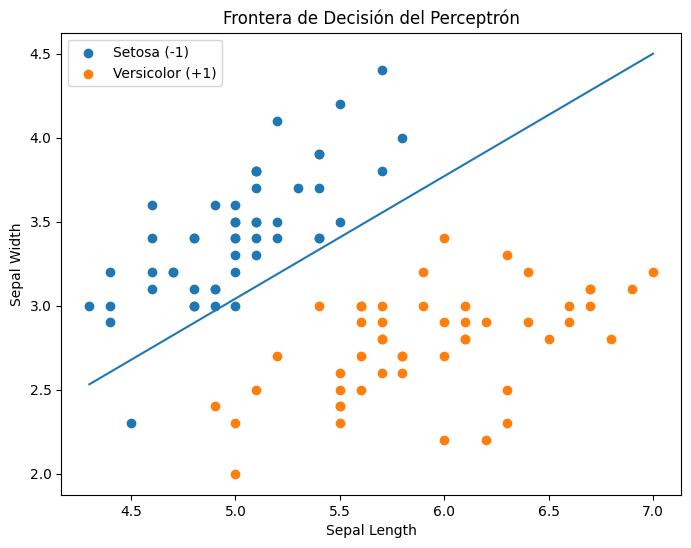

In [16]:
# GRAFICA PARA LA FRONTERA DE DECISION

# SE GRAFICAN LOS PUNTOS
plt.figure(figsize=(8,6))

# CLASE -1
plt.scatter(X[y==-1][:,0], X[y==-1][:,1], label="Setosa (-1)")

# CLASE +1
plt.scatter(X[y==1][:,0], X[y==1][:,1], label="Versicolor (+1)")

# FRONTERA DE DECISION
# w1*x1 + w2*x2 + b = 0
# SE DESPEJA x2

x_values = np.linspace(np.min(X[:,0]), np.max(X[:,0]), 100)
w1, w2 = model.weights
b = model.bias

x2_values = -(w1 * x_values + b) / w2

plt.plot(x_values, x2_values)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Frontera de Decisión del Perceptrón")
plt.legend()
plt.show()
